In [ ]:
import numpy as np
import pandas as pd
import ast
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA




# Loading Data

In [43]:
df = pd.read_pickle("data/df_train.pkl")

df_train, df_val = train_test_split(df, test_size= 0.1, random_state=42)

In [44]:
X_train = df_train.business_description_embedding.apply(ast.literal_eval).tolist()
X_train = np.array(X_train)
X_scaler = StandardScaler()
X_train = X_scaler.fit_transform(X_train)

X_val = df_val.business_description_embedding.apply(ast.literal_eval).tolist()
X_val = np.array(X_val)
X_val = X_scaler.transform(X_val)

In [45]:
df_train.head(3)

,id,industry,business_description_embedding
31138,34170,Financial Services,"[0.019633012,0.009427597,0.006240986,0.0177257..."
15120,16504,Technology Hardware & Equipment,"[0.026561439,-0.049749356,-0.006847293,-0.0088..."
23693,25893,Consumer Durables & Apparel,"[0.0115894,-0.035240766,-0.029952582,0.0226988..."


# Transforming Data (Label Encoding)

### Tasks:
- Use the scikit-learn label encoder to encode the industry names
- Check if all classes contained in the validation set are also in the training set

#

In [46]:
# Fit the label encoder to the classes (industry names)
le = LabelEncoder()
le.fit_transform(df['industry'])




array([ 1, 15,  3, ..., 23, 21,  6], shape=(31706,))

In [47]:
y_train = le.transform(df_train['industry'])
y_val =  le.transform(df_val['industry'])

np.unique(y_train)
if not all(x in np.unique(y_val) for x in np.unique(y_train)):
    raise ValueError("Training and validation sets have different number of classes after label encoding.")


# Visualize the data

### Tasks:
- Are certain classes over- or under represented? Either produce a table or a plot to show this.
- Inspect whether there is signal in the business description embeddings:
    - Perform a PCA to project data into 2 dimensions
    - Plot projected data in Scatterplot and color based on classes
    - Provide a description of what you see and judge whether there is signal in the data that allows industry classification

Important: Ensure that your plots have proper axis descriptions and titles. Style the plots so that differences in class distributions are visible (e.g. scatter size, transparency, color, etc.)

### Class distribution

C:\Users\Johannes\AppData\Local\Temp\ipykernel_10508\87769473.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=le.inverse_transform(class_counts.index), y=class_counts.values, palette="viridis")


Text(0.5, 1.0, 'Class Distribution in Training Set')

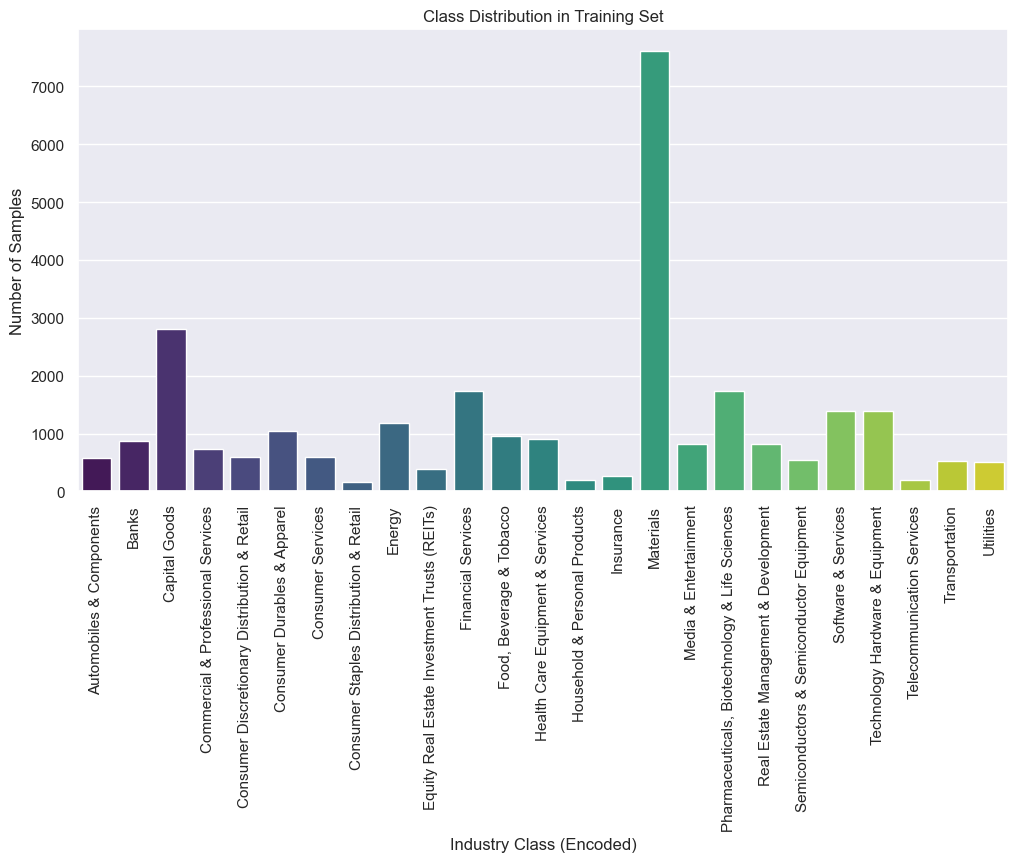

In [48]:
# Plot the class distribution or provide a table that shows how many times each class (industry) appears
# Describe your findings
class_counts = pd.Series(y_train).value_counts().sort_index()
sns.set_theme(style="whitegrid")
sns.set(rc={'figure.figsize': (12, 6)})
ax = sns.barplot(x=le.inverse_transform(class_counts.index), y=class_counts.values, palette="viridis")
ax.tick_params(axis='x', rotation=90)
ax.set_xlabel('Industry Class (Encoded)')
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution in Training Set')



### PCA - Dimensionality reduction and visualization

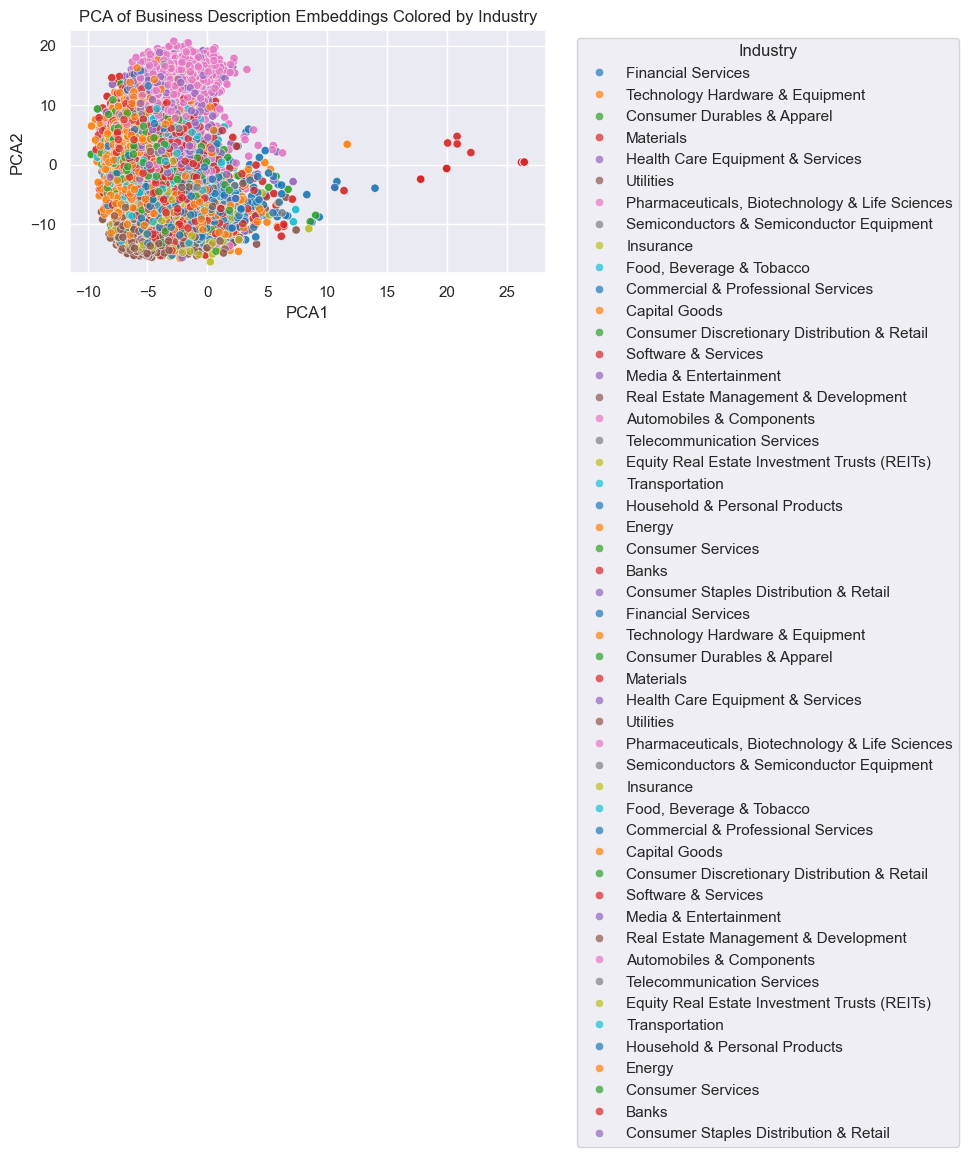

In [49]:
# Performa a PCA and plot the projected data. Color the scatter plot based on the classes
# Analyse what you see
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
df_pca = pd.DataFrame(data=X_train_pca, columns=['PCA1', 'PCA2'])
df_pca['Industry'] = le.inverse_transform(y_train)
sns.set(rc={'figure.figsize':(10,8)})
sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Industry', palette='tab10', alpha=0.7)
ax = sns.scatterplot(data=df_pca, x='PCA1', y='PCA2', hue='Industry', palette='tab10', alpha=0.7)
ax.set_title('PCA of Business Description Embeddings Colored by Industry')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Industry')
ax.figure.tight_layout()


see linear projection of data with labels. no clear clusters visible. relation is more complex then linear

# Fitting and comparing Classifier Models

### Tasks:
- Split the data into train and validation data
- Encode the industry labels using LabelEncoder (scikit-learn)
- Fit a LogisticRegression and a kNN-classifier
- Compare the model performance of both models:
    - Compute Accuracy and F1 score
        - Interpret the scores: Explain how they are computed and judge if your model performs well
        - Analyze the classification errors: 
            - Do the errors correlate with how well classes are represented?
            - Which industries does the model identify well and which seem to be similar?
    - Plot a confusion matrix for both models (combine scikit-learn confusion matrix and seaborn heatmap plot)
    - Do both models misclassify the same examples?

Import: Use proper axis labels for the plots! 

In [50]:
# your code
clf = LogisticRegression(random_state=42, max_iter=1000).fit(X_train, y_train)
y_val_pred = clf.predict(X_val)
clf_f1 = f1_score(y_val, y_val_pred, average='weighted')
clf_accuracy = clf.score(X_val, y_val)
print(f"F1 Score (Logistic Regression): {clf_f1:.4f}")
print(f"Validation Accuracy (Logistic Regression): {clf_accuracy:.4f}")

knn = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
y_val_pred_knn = knn.predict(X_val)
knn_f1 = f1_score(y_val, y_val_pred_knn, average='weighted')
knn_accuracy = knn.score(X_val, y_val)
print(f"F1 Score (KNN): {knn_f1:.4f}")
print(f"Validation Accuracy (KNN): {knn_accuracy:.4f}")


F1 Score (Logistic Regression): 0.7218
Validation Accuracy (Logistic Regression): 0.7231
F1 Score (KNN): 0.7515
Validation Accuracy (KNN): 0.7547


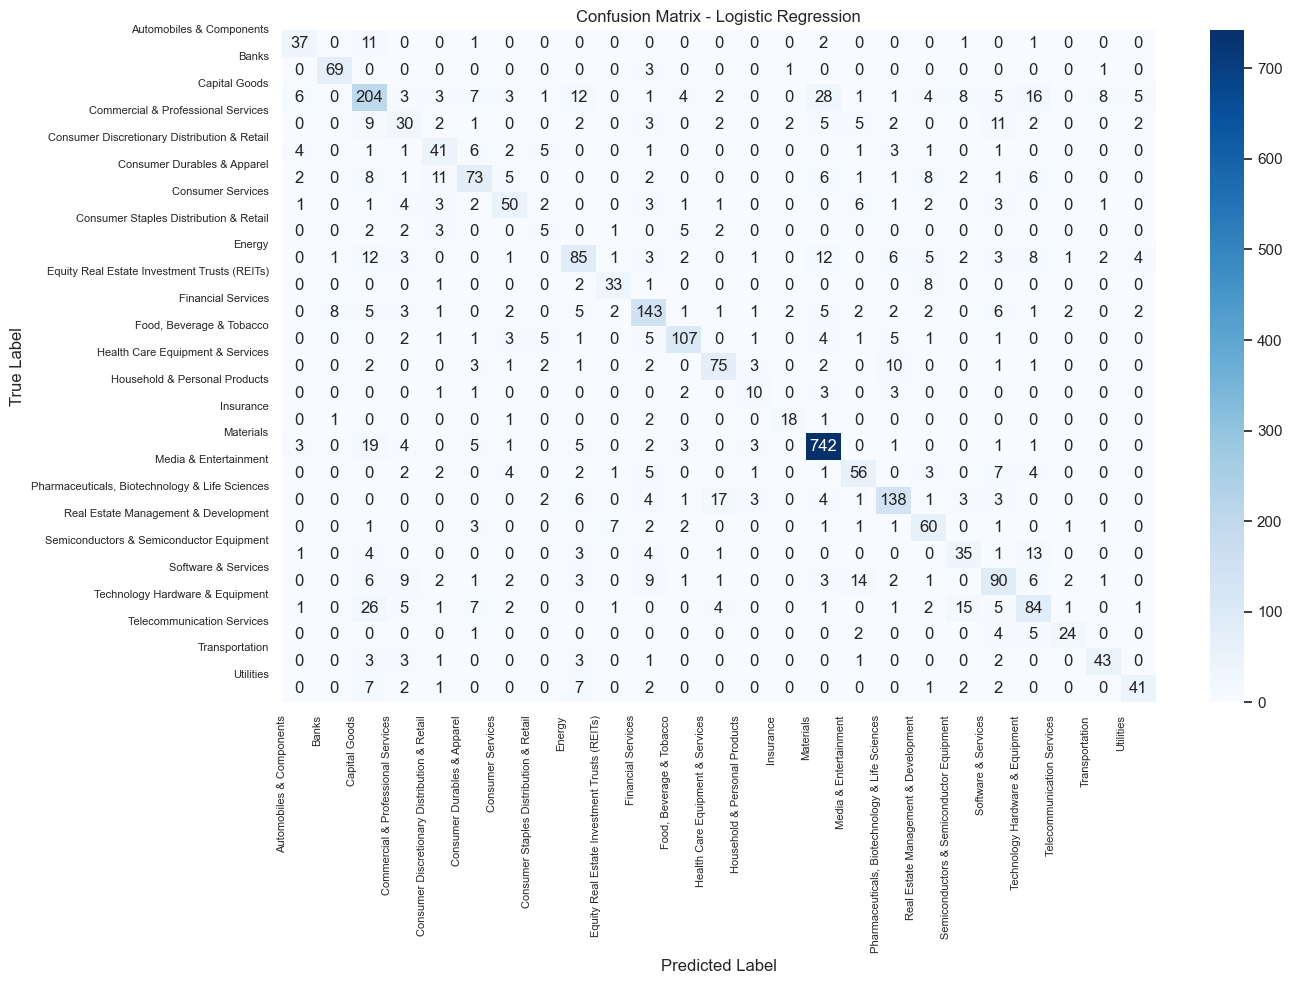

In [51]:
#confusion matrix 
clf_confusion_matrix = confusion_matrix(y_val, y_val_pred)
knn_confusion_matrix = confusion_matrix(y_val, y_val_pred_knn)

# Labels for ticks
labels = le.inverse_transform(np.arange(len(le.classes_)))

# Plot Logistic Regression confusion matrix with seaborn
sns.set(rc={'figure.figsize': (14, 10)})
ax1 = sns.heatmap(clf_confusion_matrix, annot=True, fmt='d', cmap='Blues', cbar=True)
ax1.set_title('Confusion Matrix - Logistic Regression')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_xticks(np.arange(len(labels)))
ax1.set_xticklabels(labels, rotation=90, fontsize=8)
ax1.set_yticks(np.arange(len(labels)))
ax1.set_yticklabels(labels, rotation=0, fontsize=8)
ax1.figure.tight_layout()



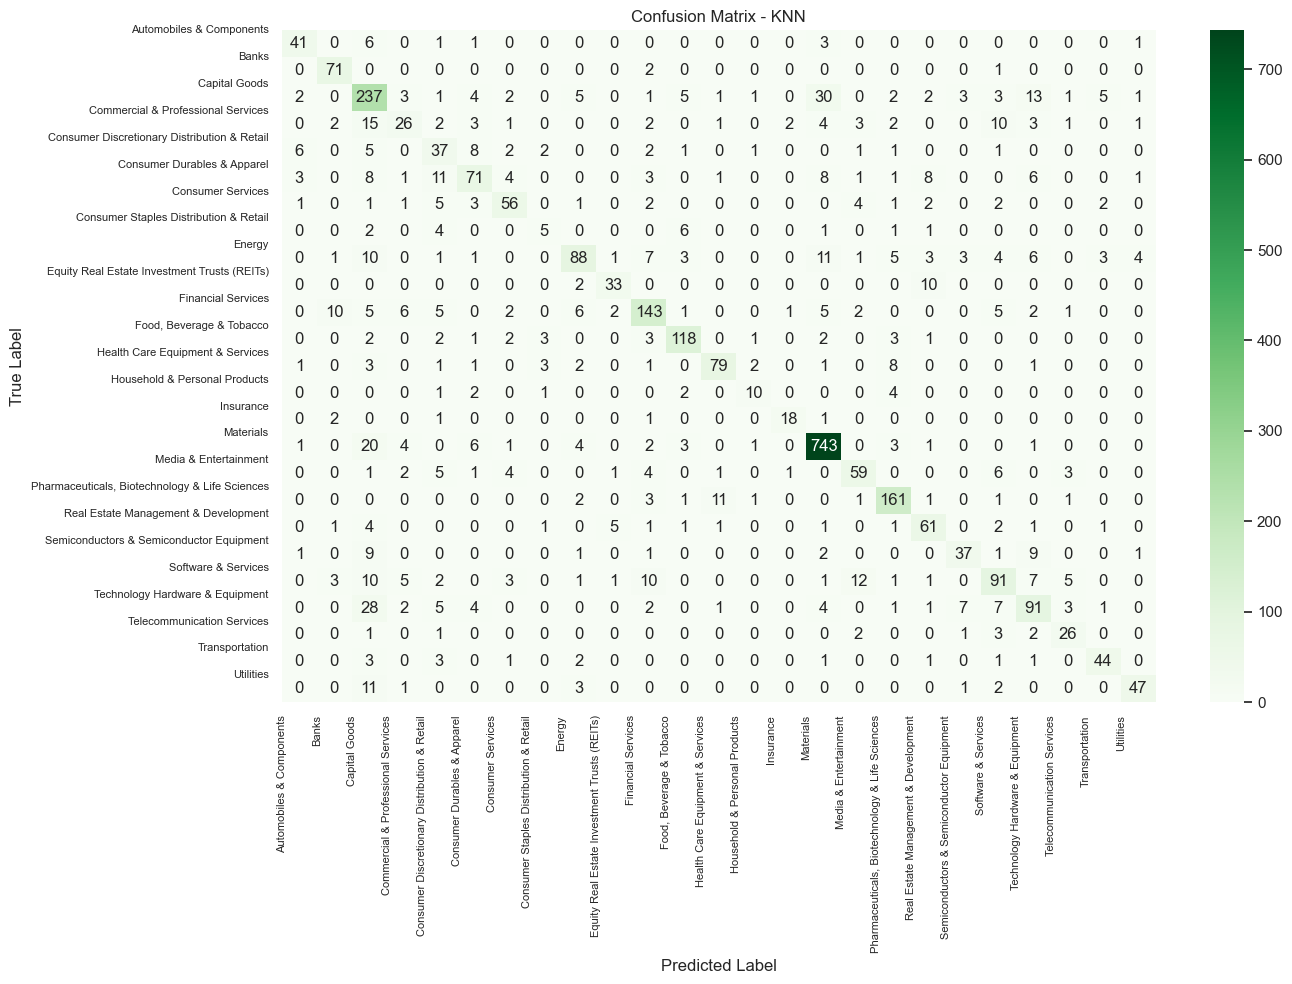

In [52]:
# Plot KNN confusion matrix with seaborn
sns.set(rc={'figure.figsize': (14, 10)})
ax2 = sns.heatmap(knn_confusion_matrix, annot=True, fmt='d', cmap='Greens', cbar=True)
ax2.set_title('Confusion Matrix - KNN')
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_xticks(np.arange(len(labels)))
ax2.set_xticklabels(labels, rotation=90, fontsize=8)
ax2.set_yticks(np.arange(len(labels)))
ax2.set_yticklabels(labels, rotation=0, fontsize=8)
ax2.figure.tight_layout()

# Optional: Confidence Weighted Prediction

## Deliverables:

- Provide a notebook with the implementation and training of a industry classifier model
- The model shall output the industry classification and its confidence as a tuple of vectors $(\hat{y}_{pred}, \hat{y}_{confidence})$
- The confidence score must be between 0 and 1, $\hat{y}_{confidence} [i] \in [0,1]$
- Your model will be evaluated on a private test set
- The designing the confidence score is your task. You may use p-values, a voting mechanism of multiple models, or other techniques
- Another option is to add more features, e.g. financial data, to X

In [53]:
def confidence_weighted_f1(y_true, y_pred, confidence):
    # Weight all predictions, not just positives
    weighted_tp = np.sum(confidence * (y_pred == 1) * (y_true == 1))
    weighted_fp = np.sum(confidence * (y_pred == 1) * (y_true == 0))
    weighted_fn = np.sum(confidence * (y_pred == 0) * (y_true == 1))
    
    precision = weighted_tp / (weighted_tp + weighted_fp) if (weighted_tp + weighted_fp) > 0 else 0
    recall = weighted_tp / (weighted_tp + weighted_fn) if (weighted_tp + weighted_fn) > 0 else 0
    
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1